# Chapter 11 — Logistic Regression

**Goals**

- See why linear regression breaks for binary classification.
- Implement logistic regression from scratch (sigmoid + binary cross-entropy + GD).
- Verify the from-scratch gradient via finite differences.
- Reproduce the result with `sklearn.linear_model.LogisticRegression`.
- Plot the decision boundary on a 2D toy.

Pair with `docs/04_classification.md`, Part C.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. Why linear regression breaks for binary classification

Fit a linear regression to a 0/1 target and watch the predictions go below 0 and above 1, which makes no sense as a probability.

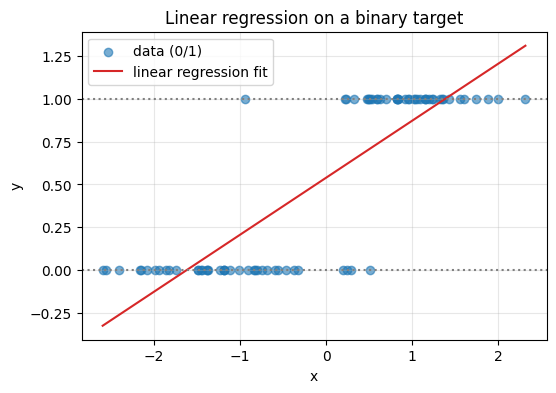

In [2]:
X_toy, y_toy = make_classification(n_samples=80, n_features=1, n_informative=1, n_redundant=0,
                                   n_clusters_per_class=1, random_state=SEED)
x_sorted = np.sort(X_toy.ravel())

from sklearn.linear_model import LinearRegression
lr_naive = LinearRegression().fit(X_toy, y_toy)
y_naive  = lr_naive.predict(x_sorted.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_toy, y_toy, alpha=0.6, label='data (0/1)')
ax.plot(x_sorted, y_naive, color='tab:red', label='linear regression fit')
ax.axhline(0, color='gray', ls=':'); ax.axhline(1, color='gray', ls=':')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Linear regression on a binary target')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

The fitted line escapes $[0, 1]$. We need to squash it through a sigmoid.

## 3. The sigmoid function

$$\sigma(z) = \frac{1}{1 + e^{-z}}.$$

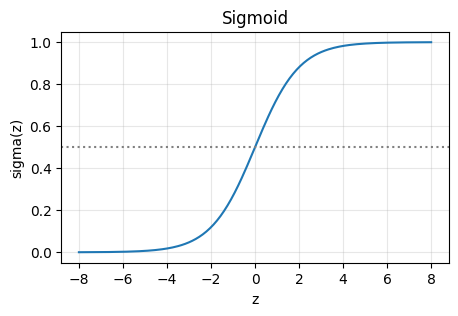

In [3]:
def sigmoid(z):
    # Numerically stable variant
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

zs = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(zs, sigmoid(zs))
ax.axhline(0.5, color='gray', ls=':')
ax.set_xlabel('z'); ax.set_ylabel('sigma(z)')
ax.set_title('Sigmoid')
ax.grid(True, alpha=0.3)
plt.show()

## 4. Logistic regression from scratch

Loss is binary cross-entropy:
$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{N}\sum_i \big[y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i)\big].$$
Gradients (with `Xb` = augmented design matrix that absorbs the bias):
$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{N} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y}).$$

In [4]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iters=2000):
        self.lr = lr
        self.n_iters = n_iters

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def fit(self, X, y):
        Xb = self._add_bias(X)
        self.w_ = np.zeros(Xb.shape[1])
        self.history_ = []
        for _ in range(self.n_iters):
            p = sigmoid(Xb @ self.w_)
            grad = (Xb.T @ (p - y)) / len(y)
            self.w_ -= self.lr * grad
            eps = 1e-12
            loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
            self.history_.append(loss)
        return self

    def predict_proba(self, X):
        return sigmoid(self._add_bias(X) @ self.w_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## 5. Verify the gradient via finite differences

In [5]:
X_check = rng.standard_normal(size=(20, 4))
y_check = (rng.random(20) > 0.5).astype(int)

def loss_fn(w_flat, Xb, y):
    p = sigmoid(Xb @ w_flat)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

Xb = np.hstack([X_check, np.ones((20, 1))])
w0 = rng.standard_normal(size=Xb.shape[1])
g_analytic = (Xb.T @ (sigmoid(Xb @ w0) - y_check)) / len(y_check)

g_numeric = np.zeros_like(w0)
h = 1e-5
for i in range(w0.size):
    e = np.zeros_like(w0); e[i] = h
    g_numeric[i] = (loss_fn(w0 + e, Xb, y_check) - loss_fn(w0 - e, Xb, y_check)) / (2 * h)

print('|g_analytic - g_numeric| =', np.linalg.norm(g_analytic - g_numeric))

|g_analytic - g_numeric| = 2.226337852698582e-11


## 6. Fit on Breast Cancer Wisconsin

Binary classification — predict malignant vs benign tumors from 30 numeric features.

In [6]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

scratch = LogisticRegressionScratch(lr=0.5, n_iters=2000).fit(X_train_s, y_train)
sk      = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_train_s, y_train)

print(f'scratch  test accuracy = {accuracy_score(y_test, scratch.predict(X_test_s)):.4f}')
print(f'sklearn  test accuracy = {accuracy_score(y_test, sk.predict(X_test_s)):.4f}')

scratch  test accuracy = 0.9825
sklearn  test accuracy = 0.9825


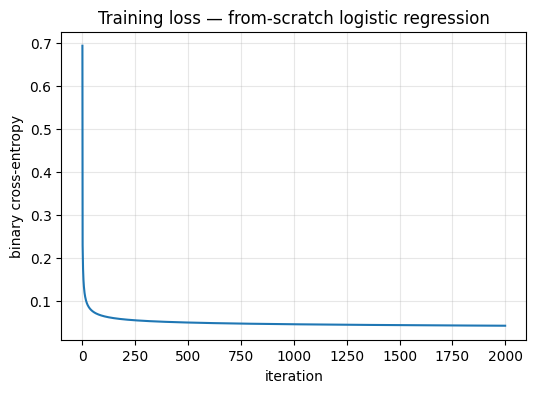

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scratch.history_)
ax.set_xlabel('iteration'); ax.set_ylabel('binary cross-entropy')
ax.set_title('Training loss — from-scratch logistic regression')
ax.grid(True, alpha=0.3)
plt.show()

## 7. Decision boundary on a 2D toy

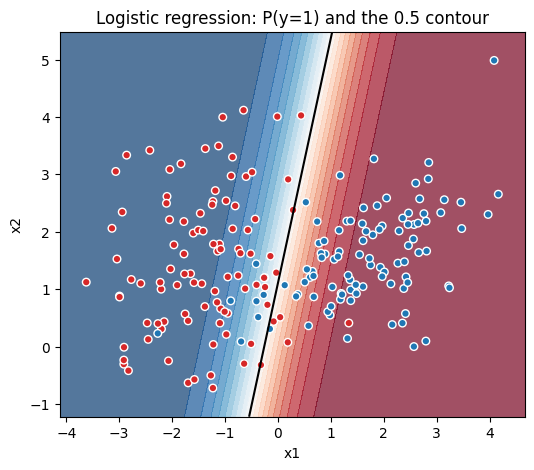

In [8]:
Xb2, yb2 = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=SEED
)
model = LogisticRegression().fit(Xb2, yb2)

xx, yy = np.meshgrid(
    np.linspace(Xb2[:, 0].min() - 0.5, Xb2[:, 0].max() + 0.5, 200),
    np.linspace(Xb2[:, 1].min() - 0.5, Xb2[:, 1].max() + 0.5, 200),
)
Z = model.predict_proba(np.column_stack([xx.ravel(), yy.ravel()]))[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
ax.contour(xx, yy, Z, levels=[0.5], colors='black')
ax.scatter(Xb2[:, 0], Xb2[:, 1], c=yb2, cmap=ListedColormap(['#d62728', '#1f77b4']), edgecolor='white', s=30)
ax.set_title('Logistic regression: P(y=1) and the 0.5 contour')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.show()

## 8. Summary

- Logistic regression = linear score → sigmoid → binary cross-entropy → gradient descent.
- From-scratch and sklearn give the same accuracy on Breast Cancer (~0.97).
- The decision boundary is a hyperplane; non-linear problems need polynomial features or kernel methods.

**Next:** `labs/lab_03_metrics_confusion_matrix.ipynb` for the full metric playground.